In [2]:
import os
import re

# -----------------------------
# CONFIG
# -----------------------------
CAM_FOLDER = r"D:\Kevin\04032026\04032026-1\cam1"   # <-- CHANGE THIS

# Regex to match filenames like: frame_030293_cnt_1575696.raw
PATTERN = re.compile(r"frame_(\d+)_cnt_(\d+)\.raw")

# -----------------------------
# LOAD AND PARSE FILENAMES
# -----------------------------
entries = []

for fname in os.listdir(CAM_FOLDER):
    m = PATTERN.match(fname)
    if not m:
        continue
    frame_idx = int(m.group(1))
    counter = int(m.group(2))
    entries.append((frame_idx, counter, fname))

if not entries:
    print("No matching files found.")
    exit()

# Sort by frame index
entries.sort(key=lambda x: x[0])

# -----------------------------
# SCAN FOR DISCREPANCIES
# -----------------------------
last_frame = None
last_counter = None

problems = []
missing_frame_index_total = 0
missing_chunk_counter_total = 0

for frame_idx, counter, fname in entries:

    if last_frame is not None:
        # Check frame index continuity
        expected_frame = last_frame + 1
        if frame_idx != expected_frame:
            gap = frame_idx - expected_frame
            missing_frame_index_total += gap
            problems.append(
                f"FRAME INDEX GAP: {last_frame} → {frame_idx} "
                f"(missing {gap} frames)"
            )

        # Check chunk counter continuity
        expected_counter = last_counter + 1
        if counter != expected_counter:
            gap = counter - expected_counter
            missing_chunk_counter_total += gap
            problems.append(
                f"CHUNK COUNTER GAP: {last_counter} → {counter} "
                f"(missing {gap} frames) "
                f"at saved frame {frame_idx} ({fname})"
            )

    last_frame = frame_idx
    last_counter = counter

# -----------------------------
# REPORT
# -----------------------------
print("\n===== INTEGRITY REPORT =====\n")

total_frames = len(entries)
print(f"Total saved frames: {total_frames}")
print(f"First frame: {entries[0][0]}, last frame: {entries[-1][0]}")
print(f"First counter: {entries[0][1]}, last counter: {entries[-1][1]}")
print()

if problems:
    print("⚠️  PROBLEMS DETECTED:\n")
    for p in problems:
        print(" - " + p)
else:
    print("✅ No discrepancies found. Frame index and chunk counters are continuous.")

print("\n----- SUMMARY OF MISSING FRAMES -----")
print(f"Missing frames by FRAME INDEX: {missing_frame_index_total}")
print(f"Missing frames by CHUNK COUNTER: {missing_chunk_counter_total}")

# Combined total (chunk counter is the real truth)
combined = missing_chunk_counter_total
print(f"TOTAL MISSING FRAMES (ground truth): {combined}")

print("\n===== END REPORT =====\n")


===== INTEGRITY REPORT =====

Total saved frames: 120268
First frame: 0, last frame: 120267
First counter: 1544909, last counter: 1678824

⚠️  PROBLEMS DETECTED:

 - CHUNK COUNTER GAP: 1572529 → 1573024 (missing 494 frames) at saved frame 27621 (frame_027621_cnt_1573024.raw)
 - CHUNK COUNTER GAP: 1575696 → 1576093 (missing 396 frames) at saved frame 30294 (frame_030294_cnt_1576093.raw)
 - CHUNK COUNTER GAP: 1579116 → 1579588 (missing 471 frames) at saved frame 33318 (frame_033318_cnt_1579588.raw)
 - CHUNK COUNTER GAP: 1582620 → 1583083 (missing 462 frames) at saved frame 36351 (frame_036351_cnt_1583083.raw)
 - CHUNK COUNTER GAP: 1586036 → 1586519 (missing 482 frames) at saved frame 39305 (frame_039305_cnt_1586519.raw)
 - CHUNK COUNTER GAP: 1591201 → 1591669 (missing 467 frames) at saved frame 43988 (frame_043988_cnt_1591669.raw)
 - CHUNK COUNTER GAP: 1594413 → 1594888 (missing 474 frames) at saved frame 46733 (frame_046733_cnt_1594888.raw)
 - CHUNK COUNTER GAP: 1598029 → 1598415 (miss

In [4]:
import os
import re
import numpy as np

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# ---- NI-DAQ TTL folder ----
ni_folder = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL" ############################################################

# ---- Camera frame folder (cam1) ----
cam_folder = r"D:\Kevin\04032026\04032026-1\cam1" ############################################################

# ============================================================
# ======================= LOAD NI TTLs ========================
# ============================================================

timestamps_ni = np.load(os.path.join(ni_folder, "timestamps.npy"))
states_ni     = np.load(os.path.join(ni_folder, "states.npy"))
full_words_ni = np.load(os.path.join(ni_folder, "full_words.npy"))

print("Loaded NI-DAQ TTL data")

# Extract TTL rising edges (camera pulses)
TTL_PIN = 0  # or 7 depending on your wiring
bit_mask = 1 << TTL_PIN

ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times = timestamps_ni[rising_edges]
TTL_COUNT = len(ttl_times)

print(f"TTL pulses detected: {TTL_COUNT}")

# ============================================================
# ======================= LOAD FRAMES =========================
# ============================================================

# Filenames like: frame_030293_cnt_1575696.raw
PATTERN = re.compile(r"frame_(\d+)_cnt_(\d+)\.raw")

entries = []

for fname in os.listdir(cam_folder):
    m = PATTERN.match(fname)
    if m:
        frame_idx = int(m.group(1))
        counter   = int(m.group(2))
        entries.append((frame_idx, counter, fname))

if not entries:
    raise RuntimeError("No frame files found in cam folder.")

# Sort by chunk counter (camera truth)
entries.sort(key=lambda x: x[1])

counters = np.array([e[1] for e in entries])
files    = [e[2] for e in entries]

print(f"Loaded {len(entries)} frame files")

# ============================================================
# =========== BUILD TTL-ALIGNED FRAME TIMELINE ===============
# ============================================================

aligned_frames = [None] * TTL_COUNT

# Map chunk counter → filename
counter_to_file = {c: f for (_, c, f) in entries}

first_counter = counters[0]

for ttl_idx in range(TTL_COUNT):
    counter_value = first_counter + ttl_idx
    aligned_frames[ttl_idx] = counter_to_file.get(counter_value, None)

np.save(os.path.join(cam_folder, "aligned_frames.npy"), aligned_frames)
# ============================================================
# ======================== SUMMARY ============================
# ============================================================

missing = sum(f is None for f in aligned_frames)

print("\n===== TTL ALIGNMENT SUMMARY =====")
print(f"TTL count:               {TTL_COUNT}")
print(f"Frames saved:            {len(entries)}")
print(f"Missing frames inserted: {missing}")
print("aligned_frames is ready for analysis.")

Loaded NI-DAQ TTL data
TTL pulses detected: 134516
Loaded 120268 frame files

===== TTL ALIGNMENT SUMMARY =====
TTL count:               134516
Frames saved:            120268
Missing frames inserted: 14248
aligned_frames is ready for analysis.


TTL pulses detected: 134516

===== DURATIONS =====
NI-DAQ duration:     2446.51 s
TTL active duration: 2243.03 s
Frame timeline:      2243.03 s


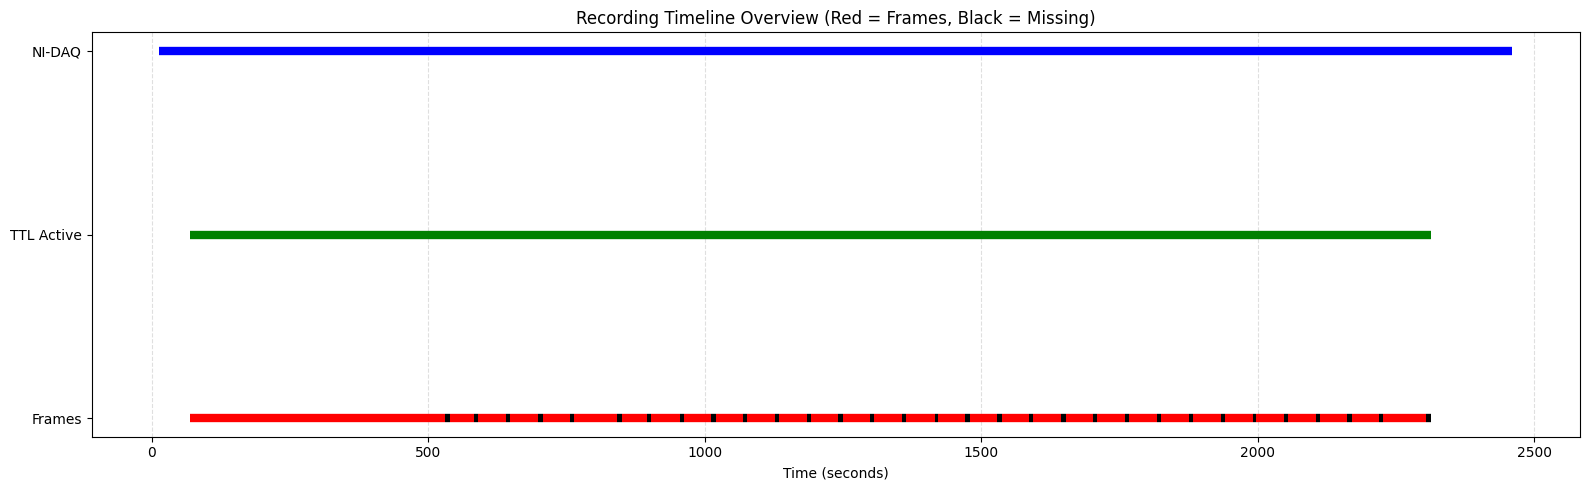

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# ---- NI-DAQ TTL folder ----
ni_folder = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"

# ---- aligned_frames list (from your TTL repair tool) ----
aligned_frames_path = r"D:\Kevin\04032026\04032026-1\cam1\aligned_frames.npy"


# ============================================================
# ======================= LOAD NI TTLs ========================
# ============================================================

timestamps_ni = np.load(os.path.join(ni_folder, "timestamps.npy"))
full_words_ni = np.load(os.path.join(ni_folder, "full_words.npy"))

TTL_PIN = 0
bit_mask = 1 << TTL_PIN

ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times = timestamps_ni[rising_edges]
TTL_COUNT = len(ttl_times)

print(f"TTL pulses detected: {TTL_COUNT}")

# ============================================================
# ======================= LOAD FRAMES =========================
# ============================================================

aligned_frames = np.load(aligned_frames_path, allow_pickle=True)
assert len(aligned_frames) == TTL_COUNT, "Mismatch: TTL count vs aligned_frames length"


# ============================================================
# ======================= DURATIONS ===========================
# ============================================================

ni_start = timestamps_ni[0]
ni_end   = timestamps_ni[-1]
ni_duration = ni_end - ni_start

ttl_start = ttl_times[0]
ttl_end   = ttl_times[-1]
ttl_duration = ttl_end - ttl_start

frame_duration = ttl_duration

print("\n===== DURATIONS =====")
print(f"NI-DAQ duration:     {ni_duration:.2f} s")
print(f"TTL active duration: {ttl_duration:.2f} s")
print(f"Frame timeline:      {frame_duration:.2f} s")


# ============================================================
# ======================= VISUALIZATION =======================
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))

# Row positions
y_ni = 3
y_ttl = 2
y_frames = 1

# --- NI-DAQ full recording ---
ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=6, label="NI-DAQ Recording")

# --- TTL active window ---
ax.hlines(y_ttl, ttl_start, ttl_end, color='green', linewidth=6, label="Camera TTL Active")

# --- Frame timeline with red (present) and black (missing) ---
for i, f in enumerate(aligned_frames):
    t0 = ttl_times[i]
    # If last TTL exists, use midpoint; else use small fixed width
    if i < TTL_COUNT - 1:
        t1 = ttl_times[i+1]
    else:
        t1 = t0 + (ttl_times[-1] - ttl_times[-2])  # last interval same width as previous

    color = 'red' if f is not None else 'black'
    ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

ax.set_yticks([y_ni, y_ttl, y_frames])
ax.set_yticklabels(["NI-DAQ", "TTL Active", "Frames"])

ax.set_xlabel("Time (seconds)")
ax.set_title("Recording Timeline Overview (Red = Frames, Black = Missing)")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
####################################   CAM 2 BELOW     ############################################################################################################################

In [7]:
import os
import re

# -----------------------------
# CONFIG
# -----------------------------
CAM_FOLDER = r"D:\Kevin\04032026\04032026-1\cam2"   # <-- CHANGE THIS

# Regex to match filenames like: frame_030293_cnt_1575696.raw
PATTERN = re.compile(r"frame_(\d+)_cnt_(\d+)\.raw")

# -----------------------------
# LOAD AND PARSE FILENAMES
# -----------------------------
entries = []

for fname in os.listdir(CAM_FOLDER):
    m = PATTERN.match(fname)
    if not m:
        continue
    frame_idx = int(m.group(1))
    counter = int(m.group(2))
    entries.append((frame_idx, counter, fname))

if not entries:
    print("No matching files found.")
    exit()

# Sort by frame index
entries.sort(key=lambda x: x[0])

# -----------------------------
# SCAN FOR DISCREPANCIES
# -----------------------------
last_frame = None
last_counter = None

problems = []
missing_frame_index_total = 0
missing_chunk_counter_total = 0

for frame_idx, counter, fname in entries:

    if last_frame is not None:
        # Check frame index continuity
        expected_frame = last_frame + 1
        if frame_idx != expected_frame:
            gap = frame_idx - expected_frame
            missing_frame_index_total += gap
            problems.append(
                f"FRAME INDEX GAP: {last_frame} → {frame_idx} "
                f"(missing {gap} frames)"
            )

        # Check chunk counter continuity
        expected_counter = last_counter + 1
        if counter != expected_counter:
            gap = counter - expected_counter
            missing_chunk_counter_total += gap
            problems.append(
                f"CHUNK COUNTER GAP: {last_counter} → {counter} "
                f"(missing {gap} frames) "
                f"at saved frame {frame_idx} ({fname})"
            )

    last_frame = frame_idx
    last_counter = counter

# -----------------------------
# REPORT
# -----------------------------
print("\n===== INTEGRITY REPORT =====\n")

total_frames = len(entries)
print(f"Total saved frames: {total_frames}")
print(f"First frame: {entries[0][0]}, last frame: {entries[-1][0]}")
print(f"First counter: {entries[0][1]}, last counter: {entries[-1][1]}")
print()

if problems:
    print("⚠️  PROBLEMS DETECTED:\n")
    for p in problems:
        print(" - " + p)
else:
    print("✅ No discrepancies found. Frame index and chunk counters are continuous.")

print("\n----- SUMMARY OF MISSING FRAMES -----")
print(f"Missing frames by FRAME INDEX: {missing_frame_index_total}")
print(f"Missing frames by CHUNK COUNTER: {missing_chunk_counter_total}")

# Combined total (chunk counter is the real truth)
combined = missing_chunk_counter_total
print(f"TOTAL MISSING FRAMES (ground truth): {combined}")

print("\n===== END REPORT =====\n")


===== INTEGRITY REPORT =====

Total saved frames: 120268
First frame: 0, last frame: 120267
First counter: 394280, last counter: 528195

⚠️  PROBLEMS DETECTED:

 - CHUNK COUNTER GAP: 421900 → 422395 (missing 494 frames) at saved frame 27621 (frame_027621_cnt_422395.raw)
 - CHUNK COUNTER GAP: 425067 → 425464 (missing 396 frames) at saved frame 30294 (frame_030294_cnt_425464.raw)
 - CHUNK COUNTER GAP: 428487 → 428959 (missing 471 frames) at saved frame 33318 (frame_033318_cnt_428959.raw)
 - CHUNK COUNTER GAP: 431990 → 432454 (missing 463 frames) at saved frame 36350 (frame_036350_cnt_432454.raw)
 - CHUNK COUNTER GAP: 435408 → 435890 (missing 481 frames) at saved frame 39305 (frame_039305_cnt_435890.raw)
 - CHUNK COUNTER GAP: 440572 → 441040 (missing 467 frames) at saved frame 43988 (frame_043988_cnt_441040.raw)
 - CHUNK COUNTER GAP: 443784 → 444259 (missing 474 frames) at saved frame 46733 (frame_046733_cnt_444259.raw)
 - CHUNK COUNTER GAP: 447400 → 447786 (missing 385 frames) at saved 

In [8]:
import os
import re
import numpy as np

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# ---- NI-DAQ TTL folder ----
ni_folder = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL" ############################################################

# ---- Camera frame folder (cam1) ----
cam_folder = r"D:\Kevin\04032026\04032026-1\cam2" ############################################################

# ============================================================
# ======================= LOAD NI TTLs ========================
# ============================================================

timestamps_ni = np.load(os.path.join(ni_folder, "timestamps.npy"))
states_ni     = np.load(os.path.join(ni_folder, "states.npy"))
full_words_ni = np.load(os.path.join(ni_folder, "full_words.npy"))

print("Loaded NI-DAQ TTL data")

# Extract TTL rising edges (camera pulses)
TTL_PIN = 1  # or 7 depending on your wiring
bit_mask = 1 << TTL_PIN

ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times = timestamps_ni[rising_edges]
TTL_COUNT = len(ttl_times)

print(f"TTL pulses detected: {TTL_COUNT}")

# ============================================================
# ======================= LOAD FRAMES =========================
# ============================================================

# Filenames like: frame_030293_cnt_1575696.raw
PATTERN = re.compile(r"frame_(\d+)_cnt_(\d+)\.raw")

entries = []

for fname in os.listdir(cam_folder):
    m = PATTERN.match(fname)
    if m:
        frame_idx = int(m.group(1))
        counter   = int(m.group(2))
        entries.append((frame_idx, counter, fname))

if not entries:
    raise RuntimeError("No frame files found in cam folder.")

# Sort by chunk counter (camera truth)
entries.sort(key=lambda x: x[1])

counters = np.array([e[1] for e in entries])
files    = [e[2] for e in entries]

print(f"Loaded {len(entries)} frame files")

# ============================================================
# =========== BUILD TTL-ALIGNED FRAME TIMELINE ===============
# ============================================================

aligned_frames = [None] * TTL_COUNT

# Map chunk counter → filename
counter_to_file = {c: f for (_, c, f) in entries}

first_counter = counters[0]

for ttl_idx in range(TTL_COUNT):
    counter_value = first_counter + ttl_idx
    aligned_frames[ttl_idx] = counter_to_file.get(counter_value, None)

np.save(os.path.join(cam_folder, "aligned_frames.npy"), aligned_frames)
# ============================================================
# ======================== SUMMARY ============================
# ============================================================

missing = sum(f is None for f in aligned_frames)

print("\n===== TTL ALIGNMENT SUMMARY =====")
print(f"TTL count:               {TTL_COUNT}")
print(f"Frames saved:            {len(entries)}")
print(f"Missing frames inserted: {missing}")
print("aligned_frames is ready for analysis.")

Loaded NI-DAQ TTL data
TTL pulses detected: 134517
Loaded 120268 frame files

===== TTL ALIGNMENT SUMMARY =====
TTL count:               134517
Frames saved:            120268
Missing frames inserted: 14249
aligned_frames is ready for analysis.


TTL pulses detected: 134517

===== DURATIONS =====
NI-DAQ duration:     2446.51 s
TTL active duration: 2243.05 s
Frame timeline:      2243.05 s


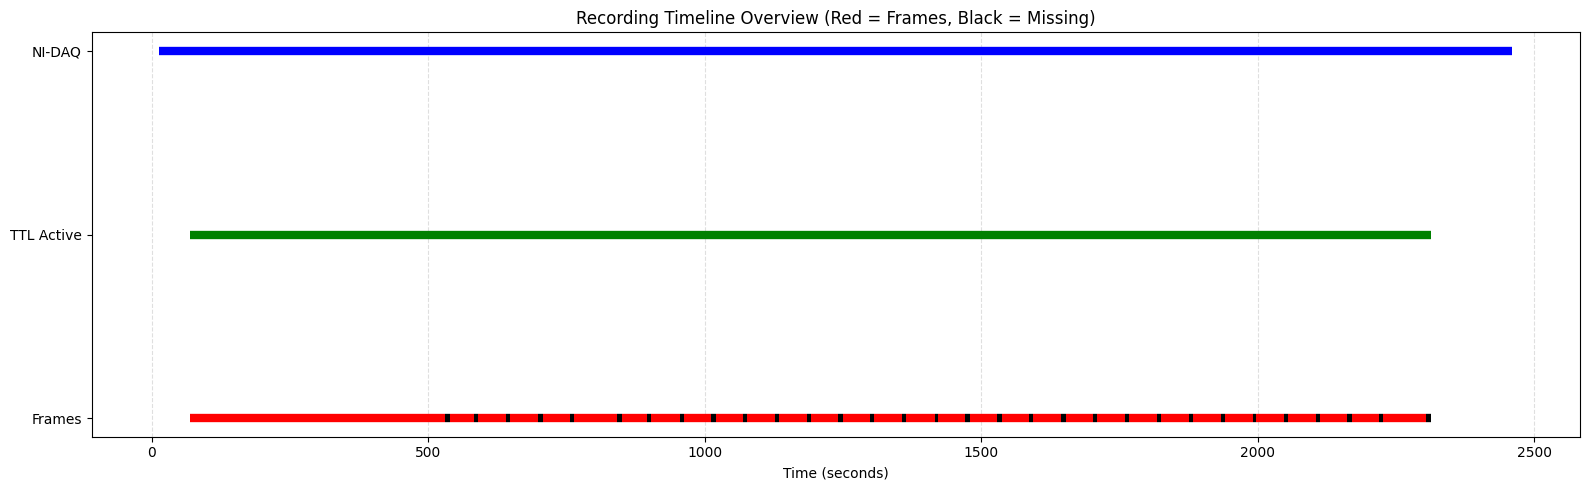

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ======================= USER INPUTS =========================
# ============================================================

# ---- NI-DAQ TTL folder ----
ni_folder = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"

# ---- aligned_frames list (from your TTL repair tool) ----
aligned_frames_path = r"D:\Kevin\04032026\04032026-1\cam2\aligned_frames.npy"


# ============================================================
# ======================= LOAD NI TTLs ========================
# ============================================================

timestamps_ni = np.load(os.path.join(ni_folder, "timestamps.npy"))
full_words_ni = np.load(os.path.join(ni_folder, "full_words.npy"))

TTL_PIN = 1
bit_mask = 1 << TTL_PIN

ttl_signal = (full_words_ni & bit_mask) > 0
ttl_diff = np.diff(ttl_signal.astype(int))
rising_edges = np.where(ttl_diff == 1)[0] + 1

ttl_times = timestamps_ni[rising_edges]
TTL_COUNT = len(ttl_times)

print(f"TTL pulses detected: {TTL_COUNT}")

# ============================================================
# ======================= LOAD FRAMES =========================
# ============================================================

aligned_frames = np.load(aligned_frames_path, allow_pickle=True)
assert len(aligned_frames) == TTL_COUNT, "Mismatch: TTL count vs aligned_frames length"


# ============================================================
# ======================= DURATIONS ===========================
# ============================================================

ni_start = timestamps_ni[0]
ni_end   = timestamps_ni[-1]
ni_duration = ni_end - ni_start

ttl_start = ttl_times[0]
ttl_end   = ttl_times[-1]
ttl_duration = ttl_end - ttl_start

frame_duration = ttl_duration

print("\n===== DURATIONS =====")
print(f"NI-DAQ duration:     {ni_duration:.2f} s")
print(f"TTL active duration: {ttl_duration:.2f} s")
print(f"Frame timeline:      {frame_duration:.2f} s")


# ============================================================
# ======================= VISUALIZATION =======================
# ============================================================

fig, ax = plt.subplots(figsize=(16, 5))

# Row positions
y_ni = 3
y_ttl = 2
y_frames = 1

# --- NI-DAQ full recording ---
ax.hlines(y_ni, ni_start, ni_end, color='blue', linewidth=6, label="NI-DAQ Recording")

# --- TTL active window ---
ax.hlines(y_ttl, ttl_start, ttl_end, color='green', linewidth=6, label="Camera TTL Active")

# --- Frame timeline with red (present) and black (missing) ---
for i, f in enumerate(aligned_frames):
    t0 = ttl_times[i]
    # If last TTL exists, use midpoint; else use small fixed width
    if i < TTL_COUNT - 1:
        t1 = ttl_times[i+1]
    else:
        t1 = t0 + (ttl_times[-1] - ttl_times[-2])  # last interval same width as previous

    color = 'red' if f is not None else 'black'
    ax.hlines(y_frames, t0, t1, color=color, linewidth=6)

ax.set_yticks([y_ni, y_ttl, y_frames])
ax.set_yticklabels(["NI-DAQ", "TTL Active", "Frames"])

ax.set_xlabel("Time (seconds)")
ax.set_title("Recording Timeline Overview (Red = Frames, Black = Missing)")
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()